# Avon River analysis — 02 Cleaning, derived measures and figures

Eric Gomez · October 2026

This notebook:
- applies the validation decisions from `01`, logging every row removed;
- derives oxygen saturation, an indicative band under New Zealand's National Policy Statement for
  Freshwater Management (NPS-FM 2020), and native/introduced flags;
- summarises every data problem in the **data validation and management matrix**, with the impact each
  would have had if it had been kept;
- describes the data and builds four figures;
- builds the alternative versions of the cleaned data used in the **sensitivity analysis**.

Formal tests are in `03`.

In [1]:
import sys, pathlib

ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == 'notebooks' else ROOT
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.visualization.theme import PALETTE, save_fig, set_plot_style
set_plot_style()

# Raw monitoring file (not included in this repository).
DATASET = 'Data_Set_Assignmnet_1 - 0426.xlsx'

In [2]:
from src.data.loading import load_raw

raw = load_raw(DATASET, header=None)            # one sheet, two tables side by side


def side_table(cols):
    """One of the two side-by-side tables, with its own header and each record's Excel row."""
    t = raw.iloc[2:, cols].copy()
    t.columns = raw.iloc[1, cols].tolist()
    t.insert(0, 'excel_row', t.index + 1)       # pandas row 0 is Excel row 1
    return t.dropna(how='all', subset=t.columns[1:]).reset_index(drop=True)


wq = side_table(slice(0, 5))      # Water Quality Data, columns A-E
fish = side_table(slice(6, 11))   # Fish Population Data, columns G-K

## Cleaning

The rules below implement the decisions in `01`. Each rule is a parameter of `clean()`, so the sensitivity
analysis can rebuild the data with any one of them changed. Every row removed is logged with its Excel row
number (`outputs/tables/02_cleaning_log.csv`).

In [3]:
# Cleaning rules from the validation in 01. The sensitivity analysis re-runs clean() with one rule changed.
RULES = dict(
    DROP_EXACT_COPIES=True,                    # data-integrity: 25 water-quality and 16 fish rows copied verbatim
    WQ_ALTERED_COPIES={                        # data-integrity: a row above with its date moved or a value changed
        77: 'row 64 (AV-3, 7 Dec) re-dated to 12 Dec',
        79: 'row 66 (AV-2, 15 Dec) re-dated to 1 Dec, DO 7.9 -> 79.9',
        83: 'row 70 (AV-3, 19 Dec) re-dated to 29 Dec, 20.7 -> 200.7 °C',
        98: 'row 30 (AV-2, 31 Oct) with the DO left blank'},
    WQ_INVALID={94: 'DO 12.9 mg/L (129% sat.): no source row, conflicts with row 69 the same day'},   # statistical outlier
    REDATE_ROWS={},                            # alternative: {64: '2023-12-12'} if row 64's date is the error, not 77's
    WQ_SAME_DAY='mean',                        # same-day readings: 'mean' (n kept) or 'first'
    FISH_ALTERED_COPIES={                      # data-integrity
        79: 'row 44 (AV-1, 8 Oct, shortfin eel) with count 3 -> 3000',
        82: 'row 22 (AV-2, 30 Oct, brown trout) re-dated to 3 Oct, count 9 -> 19',
        90: 'row 55 (AV-2, 14 Dec, longfin eel) with 19 -> 1 fish and 44.9 -> 4.9 cm'},
    FISH_INVALID={74: "date '11/31/2023' does not exist; 250 fish and 9.6 cm exceed every other īnanga"},   # data-integrity: invalid date
    SPECIES_MISSING='infer_by_size',           # missing data: 'infer_by_size' (flagged) or 'drop'
)


def clean(d):
    """Apply one set of cleaning rules. Returns one record per visit, the fish records, the species size
    ranges used for inference, and the cleaning log."""
    log = []
    def step(table, action, before, after, rows=''):
        log.append({'table': table, 'step': action, 'rows before': before, 'rows after': after, 'Excel rows': rows})

    def drop_rows(t, table, action, rows):
        n = len(t); t = t[~t.excel_row.isin(list(rows))]
        step(table, action, n, len(t), ', '.join(map(str, sorted(rows))))
        return t

    def redate(t, table):
        t = t.copy()
        for row, date in d['REDATE_ROWS'].items():
            t.loc[t.excel_row == row, 'Date'] = pd.Timestamp(date)
        if d['REDATE_ROWS']:
            step(table, 're-date rows', len(t), len(t), ', '.join(f'{r} -> {v}' for r, v in d['REDATE_ROWS'].items()))
        return t

    # ---- water quality -> one record per site-day ("visit")
    w = wq.copy()
    n = len(w)
    if d['DROP_EXACT_COPIES']:
        dup = w.duplicated([c for c in w.columns if c != 'excel_row'], keep='first')
        step('water quality', 'drop verbatim copies', n, n - dup.sum(), f'{dup.sum()} rows'); w = w[~dup]
    w = drop_rows(w, 'water quality', 'drop altered copies', d['WQ_ALTERED_COPIES'])
    w = drop_rows(w, 'water quality', 'drop invalid records', d['WQ_INVALID'])
    w = redate(w, 'water quality')
    for c in ['Temperature (°C)', 'pH', 'Dissolved Oxygen (mg/L)']:
        w[c] = pd.to_numeric(w[c])
    w['Date'] = pd.to_datetime(w['Date'])
    n = len(w)
    same_day = d['WQ_SAME_DAY']
    visits = (w.groupby(['Site ID', 'Date'], as_index=False)
                .agg(temperature_c=('Temperature (°C)', same_day), ph=('pH', same_day),
                     do_mg_l=('Dissolved Oxygen (mg/L)', same_day), n_readings=('excel_row', 'size'),
                     excel_rows=('excel_row', lambda s: ', '.join(map(str, s))))
                .rename(columns={'Site ID': 'site_id', 'Date': 'date'}))
    step('water quality', f'one record per site-day ({same_day} of same-day readings)', n, len(visits),
         '; '.join(visits.loc[visits.n_readings > 1, 'excel_rows']))

    # ---- fish
    f = fish.copy()
    n = len(f)
    if d['DROP_EXACT_COPIES']:
        dup = f.duplicated([c for c in f.columns if c != 'excel_row'], keep='first')
        step('fish', 'drop verbatim copies', n, n - dup.sum(), f'{dup.sum()} rows'); f = f[~dup]
    f = drop_rows(f, 'fish', 'drop altered copies', d['FISH_ALTERED_COPIES'])
    f = drop_rows(f, 'fish', 'drop invalid records', d['FISH_INVALID'])
    f = redate(f, 'fish')
    f['Date'] = pd.to_datetime(f['Date'])
    f['Count'] = pd.to_numeric(f['Count']).astype(int)
    f['Avg. Size (cm)'] = pd.to_numeric(f['Avg. Size (cm)'])
    ranges = f.dropna(subset=['Species']).groupby('Species')['Avg. Size (cm)'].agg(['min', 'max'])
    missing = f['Species'].isna()
    f['species_inferred'] = False
    if d['SPECIES_MISSING'] == 'infer_by_size':
        def by_size(size):
            hits = [sp for sp, r in ranges.iterrows() if r['min'] <= size <= r['max']]
            return hits[0] if len(hits) == 1 else None         # only when exactly one species fits
        f.loc[missing, 'Species'] = f.loc[missing, 'Avg. Size (cm)'].map(by_size)
        f.loc[missing, 'species_inferred'] = f.loc[missing, 'Species'].notna()
    n = len(f); rows = ', '.join(map(str, f.loc[missing, 'excel_row'])); f = f[f['Species'].notna()]
    step('fish', f"missing species: {d['SPECIES_MISSING']}", n, len(f), rows)
    fish_clean = f.rename(columns={'Site ID': 'site_id', 'Date': 'date', 'Species': 'species',
                                   'Count': 'count', 'Avg. Size (cm)': 'size_cm'})
    return visits, fish_clean, ranges, pd.DataFrame(log)


visits, fish_clean, ranges, cleaning_log = clean(RULES)

from src.visualization.presentation import save_table
print('species size ranges used for the inference (cm):'); display(ranges)
_ = save_table(cleaning_log, '02_cleaning_log')

species size ranges used for the inference (cm):


,min,max
Species,,
Brown Trout,16.6,19.5
Inanga,6.9,8.5
Longfin Eel,38.9,44.9
Shortfin Eel,38.8,42.1


saved outputs/tables/02_cleaning_log.csv

        table                                                step  rows before  rows after     Excel rows
water quality                                drop verbatim copies          100          75        25 rows
water quality                                 drop altered copies           75          71 77, 79, 83, 98
water quality                                drop invalid records           71          70             94
water quality one record per site-day (mean of same-day readings)           70          69         61, 64
         fish                                drop verbatim copies           90          74        16 rows
         fish                                 drop altered copies           74          71     79, 82, 90
         fish                                drop invalid records           71          70             74
         fish                      missing species: infer_by_size           70          70             45


### Interpretation

- **Water quality: 100 rows become 69 visits** (AV-1 19, AV-2 25, AV-3 25):
  - 25 verbatim copies and 4 altered copies removed;
  - 1 statistical outlier with no source row removed;
  - the two AV-3 readings on 7 Dec merged into one visit.
- **Fish: 90 rows become 70 species records:**
  - 16 verbatim copies and 3 altered copies removed;
  - 1 record with an invalid date removed;
  - 1 species inferred as īnanga: 8.1 cm falls only inside its range (6.9–8.5 cm).
- **The two tables now match.** Every fish record has a water reading from the same visit, and every
  visit has a fish record (checked below, after the derived measures).
- **Data quality is a finding in itself.** A quarter of the raw rows (50 of 190) were copies, altered
  copies or invalid. For an organisation that bases conservation spending on these numbers, that matters
  as much as any result below.

## Derived measures and reference data

1. **Oxygen saturation.**
   - **Formula:** `do_sat = exp(−139.34411 + 1.575701e5/T − 6.642308e7/T² + 1.243800e10/T³ − 8.621949e11/T⁴)`,
     with T in kelvin (Benson & Krause, 1984: fresh water at 1 atm).
   - **Derived from it:** `pct_sat = 100 × DO / do_sat`, and `deficit = do_sat − DO`.
   - **Why:** temperature changes how much oxygen water can hold, and the river warmed about 3 °C over the
     period.
   - **Assumes:** fresh water at sea-level pressure.
2. **Indicative NPS-FM band** from each spot DO reading: A ≥ 8.0, B 7.0–8.0, C 5.0–7.0 (bottom line 5.0),
   D < 5.0 mg/L.
   - The thresholds are NPS-FM 2020 Table 17 (rivers), which is identical to Table 7 (below point sources)
     (Ministry for the Environment, 2020).
   - **Indicative only.** The attribute is defined on the 7-day mean of *daily minima* over summer
     (1 November–30 April). A daytime reading sits above that day's minimum, but a single reading is not
     a 7-day mean, so an indicative band can be wrong in either direction.
3. **Taxon reference** (domain knowledge, cited, not taken from the data):
   - **Native:** īnanga (*Galaxias maculatus*, Threatened – Nationally Vulnerable), longfin eel
     (*Anguilla dieffenbachii*, At Risk – Declining) and shortfin eel (*A. australis*, Not Threatened).
     Statuses from the 2023 national assessment (Dunn et al., 2025). Īnanga's category reflects how little
     spawning habitat it has; its national population trend was assessed as stable.
   - **Introduced:** brown trout (*Salmo trutta*), a documented predator of native galaxiids (McDowall, 2006).

In [4]:
def do_saturation_mg_l(temp_c):
    """Benson & Krause (1984): oxygen solubility in fresh water at 1 atm, mg/L."""
    t = np.asarray(temp_c, dtype=float) + 273.15
    return np.exp(-139.34411 + 1.575701e5 / t - 6.642308e7 / t**2
                  + 1.243800e10 / t**3 - 8.621949e11 / t**4)

assert abs(do_saturation_mg_l(20.0) - 9.09) < 0.01          # published value at 20 °C

# NPS-FM 2020 Table 17 (rivers) / Table 7 (below point sources): 7-day mean minimum, mg/L.
NPSFM_BANDS = [(8.0, 'A', 'no stress'), (7.0, 'B', 'minor stress'),
               (5.0, 'C', 'moderate stress'), (-np.inf, 'D', 'significant stress')]

def indicative_band(do_mg_l):
    if pd.isna(do_mg_l):
        return None
    return next(band for floor, band, _ in NPSFM_BANDS if do_mg_l >= floor)

TAXA = pd.DataFrame([
    ('Inanga',       'Īnanga',        'native',     'Threatened – Nationally Vulnerable'),
    ('Longfin Eel',  'Longfin eel',   'native',     'At Risk – Declining'),
    ('Shortfin Eel', 'Shortfin eel',  'native',     'Not Threatened'),
    ('Brown Trout',  'Brown trout',   'introduced', 'introduced'),
], columns=['species', 'display', 'origin', 'nz_status'])
DISPLAY = dict(zip(TAXA.species, TAXA.display))

def derive(visits, fish_clean):
    """Add saturation, deficit, band and month to the visits, and join each fish record to its visit."""
    v = visits.copy()
    v['do_sat_mg_l'] = do_saturation_mg_l(v['temperature_c'])
    v['pct_sat'] = 100 * v['do_mg_l'] / v['do_sat_mg_l']
    v['deficit_mg_l'] = v['do_sat_mg_l'] - v['do_mg_l']
    v['band'] = v['do_mg_l'].map(indicative_band)
    v['month'] = v['date'].dt.to_period('M')
    r = (fish_clean.merge(TAXA[['species', 'origin', 'nz_status']], on='species', how='left', validate='many_to_one')
                   .merge(v[['site_id', 'date', 'temperature_c', 'ph', 'do_mg_l', 'pct_sat', 'band']],
                          on=['site_id', 'date'], how='left', validate='many_to_one'))
    r['month'] = r['date'].dt.to_period('M')
    assert r['origin'].notna().all(), 'a species is missing from TAXA'
    return v, r


visits, records = derive(visits, fish_clean)
print('fish records with no water-quality visit that day:',
      records.loc[records.temperature_c.isna(), ['site_id', 'date', 'species']].values.tolist())
print('visits with no fish record:',
      visits.merge(records[['site_id', 'date']].drop_duplicates(), how='left', indicator=True)
            .query('_merge == "left_only"')[['site_id', 'date']].values.tolist())

from src.data.loading import save_processed
num_v = visits.select_dtypes('number').columns
_ = save_processed(visits.assign(**visits[num_v].round(3)).drop(columns='month'), 'visits.csv')
_ = save_processed(records.drop(columns='month'), 'fish_records.csv')

fish records with no water-quality visit that day: []
visits with no fish record: []
wrote data/processed/visits.csv  (69 rows)
wrote data/processed/fish_records.csv  (70 rows)


### Interpretation

- **Both checks are empty.** Every fish record joins a water reading from the same visit, and every visit
  has at least one fish record.
- **Outputs.** `visits.csv` (69 rows) and `fish_records.csv` (70 rows) in `data/processed/` are the inputs
  to `03`.

## Data validation and management matrix

Every problem found in `01`, with its classification, the decision taken and its potential impact. The
impact is computed, not estimated: each problem record is put back on its own, everything else is cleaned
exactly as above, and the statistic the record would distort is compared with its clean value.

In [5]:
import contextlib, io
from IPython.display import Markdown


def rebuilt(**change):
    """The cleaned visits and fish records with one rule changed: the same clean() and derive() as above."""
    v, fc, _, _ = clean({**RULES, **change})
    return derive(v, fc)


def keep(rule, *rows):
    """The rule with `rows` taken off its removal list, so those records stay in."""
    return {k: s for k, s in RULES[rule].items() if k not in rows}


def december_mean(v, col='temperature_c', site=None):
    sel = (v.date.dt.month == 12) & ((v.site_id == site) if site else True)
    return v.loc[sel, col].mean()


def on_day(v, site, date, col):
    return v.loc[(v.site_id == site) & (v.date == pd.Timestamp(date)), col].iloc[0]


def n_of(k, noun):
    return f"{k} {noun}{'' if k == 1 else 's'}"


def per_survey(r, species, col='count'):
    return r.loc[r.species == species, col].mean()


def inanga_by_month(r):
    return ' / '.join(f'{x:.1f}' for x in r[r.species == 'Inanga'].groupby('month')['count'].mean())


matrix = []
def add(problem, classification, decision, impact):
    matrix.append({'Value / Problem': problem, 'Classification': classification, 'Decision': decision,
                   'Potential ecological & statistical impact': impact})


v, _ = rebuilt(WQ_ALTERED_COPIES=keep('WQ_ALTERED_COPIES', 83))
add('200.7 °C (WQ row 83)', 'Critical anomaly', 'Remove: altered copy of row 70 (20.7 °C)',
    f'December mean temperature {december_mean(visits):.1f} → {december_mean(v):.1f} °C')

v, _ = rebuilt(WQ_ALTERED_COPIES=keep('WQ_ALTERED_COPIES', 79))
add('DO 79.9 mg/L (WQ row 79)', 'Critical anomaly', 'Remove: altered copy of row 66 (7.9 mg/L)',
    f"AV-2's December mean DO {december_mean(visits, 'do_mg_l', 'AV-2'):.1f} → "
    f"{december_mean(v, 'do_mg_l', 'AV-2'):.1f} mg/L; the reading is "
    f"{on_day(v, 'AV-2', '2023-12-01', 'pct_sat'):.0f}% of saturation")

_, r = rebuilt(FISH_ALTERED_COPIES=keep('FISH_ALTERED_COPIES', 79))
add('Count 3000 (fish row 79)', 'Data-integrity error', 'Remove: altered copy of row 44 (count 3)',
    f"Shortfin eel mean count per survey {per_survey(records, 'Shortfin Eel'):.1f} → "
    f"{per_survey(r, 'Shortfin Eel'):.1f}")

_, r = rebuilt(FISH_ALTERED_COPIES=keep('FISH_ALTERED_COPIES', 90))
lost = int(records.species_inferred.sum() - r.species_inferred.sum())
add('1 longfin eel of 4.9 cm (fish row 90)', 'Data-integrity error',
    'Remove: altered copy of row 55 (19 fish of 44.9 cm)',
    f"Longfin eel mean size {per_survey(records, 'Longfin Eel', 'size_cm'):.1f} → "
    f"{per_survey(r, 'Longfin Eel', 'size_cm'):.1f} cm"
    + ("; the longfin size range would overlap īnanga's, so fish row 45's species could no longer be inferred"
       if lost else ''))

row74 = fish[fish.excel_row == 74].iloc[0]
assert row74['Species'] == 'Inanga'
n74 = int(float(row74['Count']))
ina = records.loc[records.species == 'Inanga', 'count']
add(f"Date {row74['Date']}, {n74} īnanga (fish row 74)", 'Data-integrity error',
    'Remove: impossible date, no source row',
    f"Īnanga mean count per survey {ina.mean():.1f} → {pd.concat([ina, pd.Series([n74])]).mean():.1f}; "
    'with no valid date the record cannot be placed in a month or matched to a visit')

v, r = rebuilt(WQ_ALTERED_COPIES=keep('WQ_ALTERED_COPIES', 77, 98),
               FISH_ALTERED_COPIES=keep('FISH_ALTERED_COPIES', 82))
fish_days = set(zip(r.site_id, r.date))
no_fish = sum((s, d) not in fish_days for s, d in zip(v.site_id, v.date))
no_water = int(r.temperature_c.isna().sum())
add('Other altered copies (WQ rows 77 and 98, fish row 82)', 'Data-integrity error',
    'Remove: copies of rows 64, 30 and 22',
    f'Visits {len(visits)} → {len(v)} and fish records {len(records)} → {len(r)}: surveys that never happened, '
    f"leaving {n_of(no_fish, 'visit')} without a fish record and {n_of(no_water, 'fish record')} without a water reading")

v, r = rebuilt(DROP_EXACT_COPIES=False)
m = visits.merge(v, on=['site_id', 'date'], suffixes=('', '_alt'))
shifted = int(((m.temperature_c - m.temperature_c_alt).abs() > 1e-9).sum())
add('41 verbatim copies (25 WQ rows, 16 fish rows)', 'Data-integrity error', 'Remove the copy; keep the first',
    f'Fish records {len(records)} → {len(r)}, each copy counted as a new survey (īnanga per survey, '
    f'Oct / Nov / Dec: {inanga_by_month(records)} → {inanga_by_month(r)}); water copies merge into their '
    'visits' + (f", shifting the temperature of {n_of(shifted, 'visit')} where a copy is averaged in" if shifted else ''))

v, _ = rebuilt(WQ_INVALID={})
add('DO 12.9 mg/L, 129% of saturation (WQ row 94)', 'Statistical outlier',
    'Remove: no source row; conflicts with row 69 on the same day',
    f'Visits below 7 mg/L {int((visits.do_mg_l < 7).sum())} → {int((v.do_mg_l < 7).sum())} (AV-3 on 29 Dec: '
    f"{on_day(visits, 'AV-3', '2023-12-29', 'do_mg_l'):.1f} → {on_day(v, 'AV-3', '2023-12-29', 'do_mg_l'):.1f} mg/L); "
    'both versions run in the sensitivity analysis')

add('Missing pH (WQ row 60) and size (fish row 68)', 'Missing data', 'Leave blank; no imputation',
    f'pH summarised over {visits.ph.notna().sum()} of {len(visits)} visits and size over '
    f'{records.size_cm.notna().sum()} of {len(records)} records; neither enters a hypothesis test')

_, r = rebuilt(SPECIES_MISSING='drop')
add('Missing species (fish row 45, copied at 80)', 'Missing data', 'Infer īnanga from its size (8.1 cm) and flag it',
    f"Dropped instead: īnanga records {int((records.species == 'Inanga').sum())} → {int((r.species == 'Inanga').sum())}, "
    f'per survey Oct / Nov / Dec {inanga_by_month(records)} → {inanga_by_month(r)}; '
    'both versions run in the sensitivity analysis')

matrix = pd.DataFrame(matrix)
rows = ['| ' + ' | '.join(matrix.columns) + ' |', '|' + '---|' * len(matrix.columns)]
rows += ['| ' + ' | '.join(map(str, r)) + ' |' for r in matrix.values]
display(Markdown('\n'.join(rows)))
with contextlib.redirect_stdout(io.StringIO()):          # the table is shown above; save it quietly
    path = save_table(matrix, '02_validation_matrix')
print(f'saved outputs/tables/{path.name}')

| Value / Problem | Classification | Decision | Potential ecological & statistical impact |
|---|---|---|---|
| 200.7 °C (WQ row 83) | Critical anomaly | Remove: altered copy of row 70 (20.7 °C) | December mean temperature 18.1 → 23.0 °C |
| DO 79.9 mg/L (WQ row 79) | Critical anomaly | Remove: altered copy of row 66 (7.9 mg/L) | AV-2's December mean DO 7.8 → 16.8 mg/L; the reading is 854% of saturation |
| Count 3000 (fish row 79) | Data-integrity error | Remove: altered copy of row 44 (count 3) | Shortfin eel mean count per survey 5.9 → 255.4 |
| 1 longfin eel of 4.9 cm (fish row 90) | Data-integrity error | Remove: altered copy of row 55 (19 fish of 44.9 cm) | Longfin eel mean size 42.8 → 40.3 cm; the longfin size range would overlap īnanga's, so fish row 45's species could no longer be inferred |
| Date 11/31/2023, 250 īnanga (fish row 74) | Data-integrity error | Remove: impossible date, no source row | Īnanga mean count per survey 19.9 → 28.8; with no valid date the record cannot be placed in a month or matched to a visit |
| Other altered copies (WQ rows 77 and 98, fish row 82) | Data-integrity error | Remove: copies of rows 64, 30 and 22 | Visits 69 → 70 and fish records 70 → 71: surveys that never happened, leaving 1 visit without a fish record and 1 fish record without a water reading |
| 41 verbatim copies (25 WQ rows, 16 fish rows) | Data-integrity error | Remove the copy; keep the first | Fish records 70 → 86, each copy counted as a new survey (īnanga per survey, Oct / Nov / Dec: 22.5 / 23.0 / 10.8 → 22.8 / 22.5 / 12.1); water copies merge into their visits, shifting the temperature of 1 visit where a copy is averaged in |
| DO 12.9 mg/L, 129% of saturation (WQ row 94) | Statistical outlier | Remove: no source row; conflicts with row 69 on the same day | Visits below 7 mg/L 12 → 11 (AV-3 on 29 Dec: 6.9 → 9.9 mg/L); both versions run in the sensitivity analysis |
| Missing pH (WQ row 60) and size (fish row 68) | Missing data | Leave blank; no imputation | pH summarised over 68 of 69 visits and size over 69 of 70 records; neither enters a hypothesis test |
| Missing species (fish row 45, copied at 80) | Missing data | Infer īnanga from its size (8.1 cm) and flag it | Dropped instead: īnanga records 25 → 24, per survey Oct / Nov / Dec 22.5 / 23.0 / 10.8 → 22.0 / 23.0 / 10.8; both versions run in the sensitivity analysis |

saved outputs/tables/02_validation_matrix.csv


### Interpretation

- **The critical anomalies sit inside copies.** Both impossible values (200.7 °C and 79.9 mg/L) are altered
  copies of genuine readings, so removing the copy removes the anomaly and the true reading stays in.
- **Single records would have distorted the headline numbers.** Kept, 200.7 °C would lift December's mean
  temperature from 18.1 to 23.0 °C, and the 3000 count would put shortfin eel at 255 fish per survey instead
  of 5.9.
- **Errors can interact.** The 4.9 cm "longfin eel" would stretch the longfin size range over īnanga's, and
  the species of fish row 45 could then no longer be inferred.
- **Copies inflate the sample as well as the numbers.** The 41 verbatim copies would turn 70 fish records
  into 86, so the tests would count the same survey more than once.
- **The two judgement calls move little.** Keeping row 94 lifts one visit above 7 mg/L (12 → 11 visits
  below it), and dropping the inferred species changes only October's īnanga mean (22.5 → 22.0). `03`
  shows that neither changes a conclusion.

In [6]:
sites = visits.groupby('site_id').agg(
    visits=('date', 'size'), temp_median=('temperature_c', 'median'), temp_max=('temperature_c', 'max'),
    do_median=('do_mg_l', 'median'), do_min=('do_mg_l', 'min'),
    sat_median=('pct_sat', 'median'), sat_min=('pct_sat', 'min'),
    visits_below_7=('do_mg_l', lambda s: int((s < 7).sum())))
months = visits.groupby('month').agg(visits=('date', 'size'), temp_mean=('temperature_c', 'mean'),
                                     do_mean=('do_mg_l', 'mean'), sat_mean=('pct_sat', 'mean'))
display(sites.round(2)); display(months.round(2))
print('visits below saturation:', int((visits.pct_sat < 100).sum()), 'of', int(visits.pct_sat.notna().sum()),
      '| below 75% saturation:', int((visits.pct_sat < 75).sum()),
      '| below 7 mg/L:', int((visits.do_mg_l < 7).sum()))
ph = visits.ph.dropna()
print(f'pH: {ph.min():.2f}–{ph.max():.2f} over {len(ph)} visits | below 7.2: {int((ph < 7.2).sum())}'
      f' | above 7.8: {int((ph > 7.8).sum())}   (ANZECC 2000 default range for NZ lowland rivers: 7.2–7.8)')
_ = save_table(sites.round(2).reset_index(), '02_site_summary')
_ = save_table(months.round(2).reset_index().astype({'month': str}), '02_month_summary')

,visits,temp_median,temp_max,do_median,do_min,sat_median,sat_min,visits_below_7
site_id,,,,,,,,
AV-1,19,14.1,19.4,7.80,6.8,75.52,65.98,3
AV-2,25,15.8,20.7,8.20,6.7,83.38,67.88,4
AV-3,25,17.9,20.7,7.55,6.5,80.10,67.10,5


,visits,temp_mean,do_mean,sat_mean
month,,,,
2023-10,29,14.97,7.94,78.76
2023-11,21,16.61,7.95,81.51
2023-12,19,18.11,7.69,81.49


visits below saturation: 69 of 69 | below 75% saturation: 21 | below 7 mg/L: 12
pH: 7.04–7.88 over 68 visits | below 7.2: 10 | above 7.8: 1   (ANZECC 2000 default range for NZ lowland rivers: 7.2–7.8)
saved outputs/tables/02_site_summary.csv

site_id  visits  temp_median  temp_max  do_median  do_min  sat_median  sat_min  visits_below_7
   AV-1      19         14.1      19.4       7.80     6.8       75.52    65.98               3
   AV-2      25         15.8      20.7       8.20     6.7       83.38    67.88               4
   AV-3      25         17.9      20.7       7.55     6.5       80.10    67.10               5
saved outputs/tables/02_month_summary.csv

  month  visits  temp_mean  do_mean  sat_mean
2023-10      29      14.97     7.94     78.76
2023-11      21      16.61     7.95     81.51
2023-12      19      18.11     7.69     81.49


### Interpretation

- **Warming.** The river warmed from a monthly mean of **15.0 °C in October to 18.1 °C in December**.
  - **AV-3 ran warmest:** median 17.9 °C against 15.8 °C at AV-2 and 14.1 °C at AV-1.
  - AV-2 and AV-3 both peaked at 20.7 °C.
- **Oxygen below saturation everywhere.** **All 69 visits were below full saturation**
  (66–98%, median 81%). 21 visits were under 75%.
- **Lower bands at every site.** **12 visits fell below 7 mg/L**, the start of NPS-FM band C: 3 at AV-1,
  4 at AV-2 and 5 at AV-3. AV-1's three were all in October. From 1 November, when the NPS-FM summer
  window opens, only AV-2 (2) and AV-3 (5) fell below 7 mg/L. Because these are daytime spot readings, the
  dawn minima were lower still.
- **pH is not a key challenge.** It ran 7.04–7.88 over 68 visits. 10 readings sat just below the 7.2
  lower guideline for NZ lowland rivers and 1 just above 7.8 (ANZECC, 2000), none far outside it.

In [7]:
fish_site = pd.crosstab(records.species.map(DISPLAY), records.site_id)
fish_month = records.pivot_table(index=records.species.map(DISPLAY), columns=records.month.astype(str),
                                 values='count', aggfunc=['size', 'mean']).round(1)
size_month = records.pivot_table(index=records.species.map(DISPLAY), columns=records.month.astype(str),
                                 values='size_cm', aggfunc='mean').round(1)
display(fish_site); display(fish_month); display(size_month)
_ = save_table(fish_month.reset_index(), '02_fish_by_month')
_ = save_table(size_month.reset_index(), '02_fish_size_by_month')

site_id,AV-1,AV-2,AV-3
species,,,
Brown trout,4,7,8
Longfin eel,5,5,5
Shortfin eel,4,4,3
Īnanga,6,9,10


size                    mean                
month        2023-10 2023-11 2023-12 2023-10 2023-11 2023-12
species                                                     
Brown trout        7       5       7    10.1    11.0    15.4
Longfin eel        7       2       6     4.9     5.5    12.5
Shortfin eel       7       3       1     5.6     7.0     5.0
Īnanga             8      11       6    22.5    23.0    10.8

month,2023-10,2023-11,2023-12
species,,,
Brown trout,17.9,18.5,17.6
Longfin eel,42.6,41.0,43.7
Shortfin eel,40.1,40.9,39.6
Īnanga,7.6,7.7,7.6


saved outputs/tables/02_fish_by_month.csv

     species    size                    mean                
             2023-10 2023-11 2023-12 2023-10 2023-11 2023-12
 Brown trout       7       5       7    10.1    11.0    15.4
 Longfin eel       7       2       6     4.9     5.5    12.5
Shortfin eel       7       3       1     5.6     7.0     5.0
      Īnanga       8      11       6    22.5    23.0    10.8
saved outputs/tables/02_fish_size_by_month.csv

     species  2023-10  2023-11  2023-12
 Brown trout     17.9     18.5     17.6
 Longfin eel     42.6     41.0     43.7
Shortfin eel     40.1     40.9     39.6
      Īnanga      7.6      7.7      7.6


### Interpretation

- **Where each species was recorded.** All four species were recorded at all three sites. Introduced
  brown trout appear in 19 of 70 records.
- **Īnanga per survey: 22.5 (Oct, n = 8), 23.0 (Nov, n = 11) and 10.8 (Dec, n = 6).**
  - The December mean is less than half the earlier months'.
  - `03` tests whether this is more than chance.
- **Counts that rose in December.**
  - Brown trout (introduced): 10.1 → 11.0 → 15.4.
  - Longfin eel (native): 4.9 → 5.5 → 12.5.
- **Fish size didn't change.** Mean size by month barely moved for any species (īnanga 7.6, 7.7 and
  7.6 cm), so the December change is in numbers, not size.
- **The limit on all of these.** Survey effort isn't recorded, so these are counts per survey, not densities.

## Correlation method: Spearman

- **Why Spearman, not Pearson:**
  - counts are skewed and tied;
  - n per species is only 11–25;
  - nothing suggests a linear form.
  Spearman's rank correlation needs only a monotonic relationship and is robust to the remaining extremes.
- **Exploratory here.** The correlations below are exploratory. The pre-stated tests, with a correction
  for testing several hypotheses at once, are in `03`.

In [8]:
from scipy import stats

rows = []
for sp, g in records.dropna(subset=['pct_sat']).groupby('species'):
    for var in ['pct_sat', 'do_mg_l', 'temperature_c', 'ph']:
        d = g[[var, 'count']].dropna()
        rho, p = stats.spearmanr(d[var], d['count'])
        rows.append({'species': DISPLAY[sp], 'variable': var, 'n': len(d), 'rho': round(rho, 2), 'p (unadjusted)': round(p, 3)})
explore = pd.DataFrame(rows).pivot(index='species', columns='variable', values='rho')
display(explore)
_ = save_table(pd.DataFrame(rows), '02_spearman_exploratory')

variable,do_mg_l,pct_sat,ph,temperature_c
species,,,,
Brown trout,-0.28,-0.31,-0.23,0.05
Longfin eel,0.08,0.20,0.43,0.46
Shortfin eel,0.17,0.27,0.42,0.50
Īnanga,-0.05,-0.16,-0.19,-0.21


saved outputs/tables/02_spearman_exploratory.csv

     species      variable  n   rho  p (unadjusted)
 Brown trout       pct_sat 19 -0.31           0.196
 Brown trout       do_mg_l 19 -0.28           0.240
 Brown trout temperature_c 19  0.05           0.842
 Brown trout            ph 19 -0.23           0.344
      Īnanga       pct_sat 25 -0.16           0.436
      Īnanga       do_mg_l 25 -0.05           0.810
      Īnanga temperature_c 25 -0.21           0.306
      Īnanga            ph 25 -0.19           0.359
 Longfin eel       pct_sat 15  0.20           0.484
 Longfin eel       do_mg_l 15  0.08           0.769
 Longfin eel temperature_c 15  0.46           0.082
 Longfin eel            ph 14  0.43           0.123
Shortfin eel       pct_sat 11  0.27           0.417
Shortfin eel       do_mg_l 11  0.17           0.624
Shortfin eel temperature_c 11  0.50           0.114
Shortfin eel            ph 11  0.42           0.198


### Interpretation

- **No strong relationships.** No species' count has a strong rank correlation with oxygen, saturation,
  temperature or pH. Every |ρ| is at most about 0.5, and none is significant even before correction.
  The closest is longfin eel against temperature (ρ = 0.46, p = 0.08, n = 15).
- **What that does and doesn't mean.** At these sample sizes this is "not detected", not "no effect".
  A modest relationship would need many more surveys to show.

## Figures

Four figures, saved as 150-dpi PNGs in `outputs/figures/`:

- **Figure A (temperature)** and **Figure B (oxygen)** show the two environmental pressures in the data.
- **Figure C (river-check grid)** and **Figure D (fish per survey, by species and month)** are designed for
  non-specialist readers, such as a board or the public.

Design rules (Knaflic, 2015; Wilke, 2019):
- the title states the finding;
- one highlight, the rest grey;
- redundant coding, so the meaning never depends on colour alone;
- a sequential pale → dark band ramp, checked for colour blindness and greyscale;
- no dual axes;
- direct labels instead of legends where possible.

saved outputs/figures/02_A_temperature.png


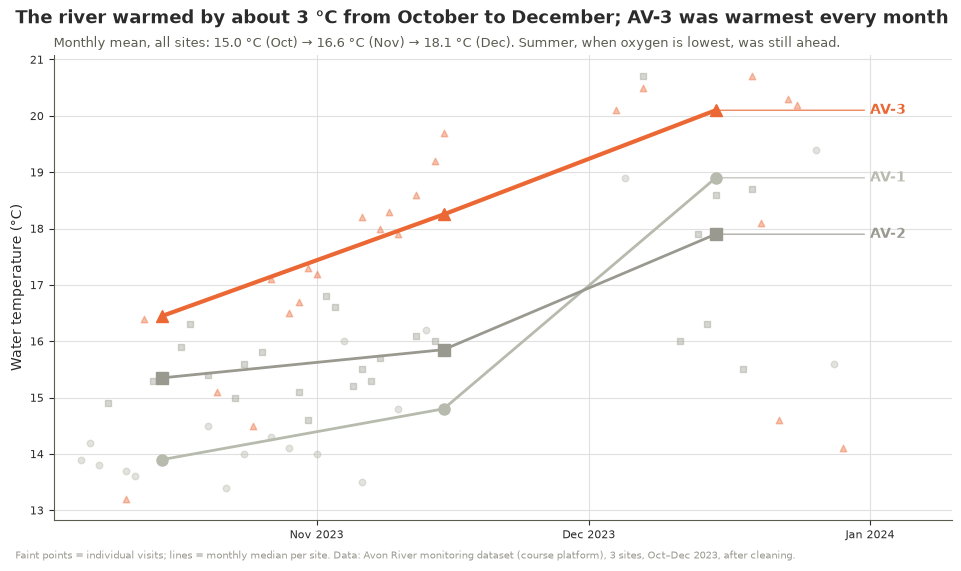

temperature vs date: Spearman rho = 0.63, p = 7e-09, n = 69 visits


In [9]:
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch

SITES = ['AV-1', 'AV-2', 'AV-3']
HIGHLIGHT = 'AV-3'
SITE_STYLE = {'AV-1': (PALETTE['context'], 'o'), 'AV-2': (PALETTE['baseline'], 's'), 'AV-3': (PALETTE['alert'], '^')}
BAND_STYLE = {'A': ('#d1e5f0', PALETTE['text']), 'B': ('#92c5de', PALETTE['text']),
              'C': ('#e07b5f', PALETTE['text']), 'D': ('#b2182b', 'white')}   # pale -> dark, checked below
SHORT = {b: lbl for _, b, lbl in NPSFM_BANDS}
SOURCE = 'Data: Avon River monitoring dataset (course platform), 3 sites, Oct–Dec 2023, after cleaning.'

def finding_title(fig, ax, title, subtitle):
    fig.suptitle(title, x=0.01, ha='left', fontsize=13)
    ax.set_title(subtitle, loc='left', fontsize=9, fontweight='normal', color=PALETTE['rule'])

def footnote(fig, text):
    fig.text(0.01, -0.01, text, ha='left', va='top', fontsize=7.5, color=PALETTE['baseline'])

fig, ax = plt.subplots(figsize=(9.5, 5.4), layout='constrained')
monthly = (visits.groupby(['site_id', 'month']).temperature_c.median().rename('median').reset_index())
monthly['mid'] = monthly['month'].dt.start_time + pd.Timedelta(days=14)      # plot each month at its middle
ends = {}
for site in SITES:
    s = visits[visits.site_id == site]
    m = monthly[monthly.site_id == site]
    colour, marker = SITE_STYLE[site]
    hi = site == HIGHLIGHT
    ax.scatter(s.date, s.temperature_c, color=colour, marker=marker, s=22, alpha=0.4, zorder=2)
    ax.plot(m['mid'], m['median'], color=colour, lw=3 if hi else 2, marker=marker, ms=8, zorder=3)
    ends[site] = m['median'].iloc[-1]
# direct labels at the right, nudged apart so they never overlap
placed = {}
for site, y in sorted(ends.items(), key=lambda kv: kv[1]):
    y_lab = max([y] + [v + 0.55 for v in placed.values()])
    placed[site] = y_lab
    colour, _ = SITE_STYLE[site]
    ax.annotate(site, (monthly['mid'].max(), ends[site]), xytext=(visits.date.max() + pd.Timedelta(days=3), y_lab),
                va='center', fontsize=10, fontweight='bold', color=colour,
                arrowprops=dict(arrowstyle='-', color=colour, lw=0.8))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(visits.date.min() - pd.Timedelta(days=3), visits.date.max() + pd.Timedelta(days=12))
ax.set_ylabel('Water temperature (°C)')
footnote(fig, 'Faint points = individual visits; lines = monthly median per site. ' + SOURCE)
monthly_means = ' → '.join(f'{t:.1f} °C ({m.strftime("%b")})' for m, t in months.temp_mean.items())
finding_title(fig, ax, 'The river warmed by about 3 °C from October to December; AV-3 was warmest every month',
              f'Monthly mean, all sites: {monthly_means}. Summer, when oxygen is lowest, was still ahead.')
fig_a = save_fig(fig, '02_A_temperature')
plt.show()
rho, p = stats.spearmanr(visits.date.map(pd.Timestamp.toordinal), visits.temperature_c)
print(f'temperature vs date: Spearman rho = {rho:.2f}, p = {p:.1g}, n = {len(visits)} visits')

### Interpretation — Figure A

- **Warming.** Temperature rose at every site through late spring. The rank correlation with date is
  ρ = 0.63 (p < 0.001, printed above).
- **AV-3 warmest.** AV-3 was the warmest site in each month.
- **Why it matters.** Warmer water holds less oxygen, and the summer low-flow period, when the NPS-FM
  oxygen attribute applies, was still to come. The data stop at 29 December.

saved outputs/figures/02_B_oxygen_saturation.png


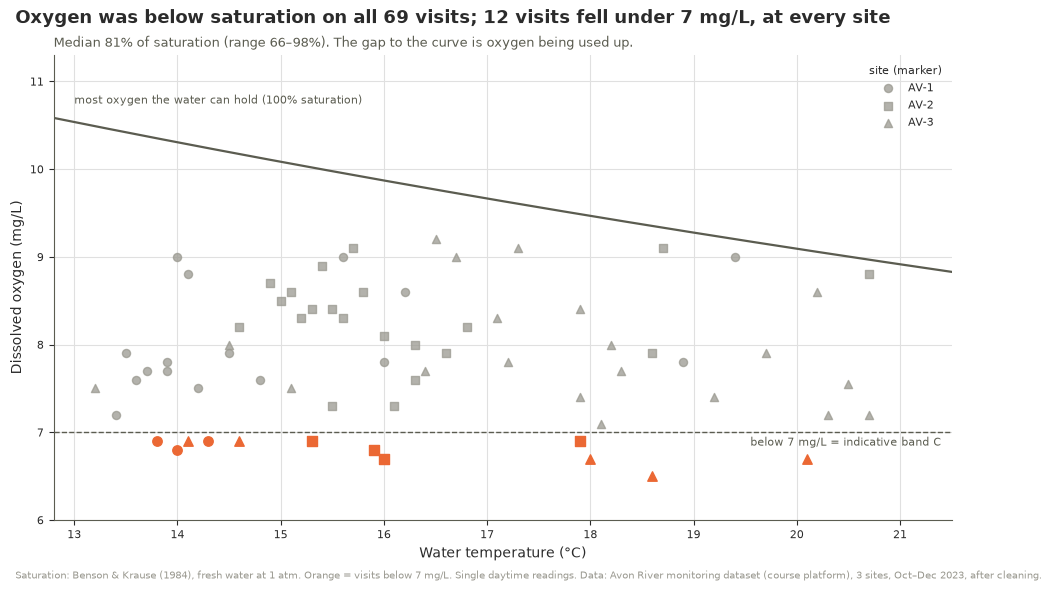

DO vs temperature: Spearman rho = 0.05, p = 0.67, n = 69 visits


In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.6), layout='constrained')
t_grid = np.linspace(12.8, 21.5, 200)
ax.plot(t_grid, do_saturation_mg_l(t_grid), color=PALETTE['rule'], lw=1.6)
ax.text(13.0, do_saturation_mg_l(13.0) + 0.18, 'most oxygen the water can hold (100% saturation)',
        ha='left', va='bottom', fontsize=8, color=PALETTE['rule'])
ax.axhline(7.0, color=PALETTE['rule'], lw=1, ls='--')
ax.text(21.4, 6.95, 'below 7 mg/L = indicative band C', ha='right', va='top', fontsize=8, color=PALETTE['rule'])
d = visits.dropna(subset=['do_mg_l'])
for site in SITES:
    s = d[d.site_id == site]
    _, marker = SITE_STYLE[site]
    low = s.do_mg_l < 7
    ax.scatter(s.temperature_c[~low], s.do_mg_l[~low], marker=marker, s=34, color=PALETTE['baseline'],
               alpha=0.75, label=f'{site}', zorder=3)
    ax.scatter(s.temperature_c[low], s.do_mg_l[low], marker=marker, s=46, color=PALETTE['alert'], zorder=4)
ax.legend(title='site (marker)', loc='upper right', frameon=False, fontsize=8, title_fontsize=8)
ax.set_xlim(12.8, 21.5); ax.set_ylim(6.0, 11.3)
ax.set_xlabel('Water temperature (°C)'); ax.set_ylabel('Dissolved oxygen (mg/L)')
n_low, n_all = int((d.do_mg_l < 7).sum()), len(d)
footnote(fig, 'Saturation: Benson & Krause (1984), fresh water at 1 atm. Orange = visits below 7 mg/L. Single daytime readings. ' + SOURCE)
finding_title(fig, ax, f'Oxygen was below saturation on all {n_all} visits; {n_low} visits fell under 7 mg/L, at every site',
              f'Median {d.pct_sat.median():.0f}% of saturation (range {d.pct_sat.min():.0f}–{d.pct_sat.max():.0f}%). '
              'The gap to the curve is oxygen being used up.')
fig_b = save_fig(fig, '02_B_oxygen_saturation')
plt.show()
rho_t, p_t = stats.spearmanr(d.temperature_c, d.do_mg_l)
print(f'DO vs temperature: Spearman rho = {rho_t:.2f}, p = {p_t:.2f}, n = {len(d)} visits')

### Interpretation — Figure B

- **Every point is below the curve.** The water never held as much oxygen as it could. Something
  consumed it: decomposing organic matter, sediment, or plant respiration.
- **Under 7 mg/L at every site.** Orange points are visits under 7 mg/L, and they occur at all three sites.
- **Daytime readings flatter the river.** These are daytime spot samples, and DO is lowest around dawn.
  So the true minima are lower than anything plotted here (Ministry for the Environment, 2018, s. 6).
- **No relationship with temperature in these data** (ρ = 0.05, p = 0.67, printed above). Within this range, temperature alone
  doesn't explain the oxygen readings.

saved outputs/figures/02_C_river_check_grid.png


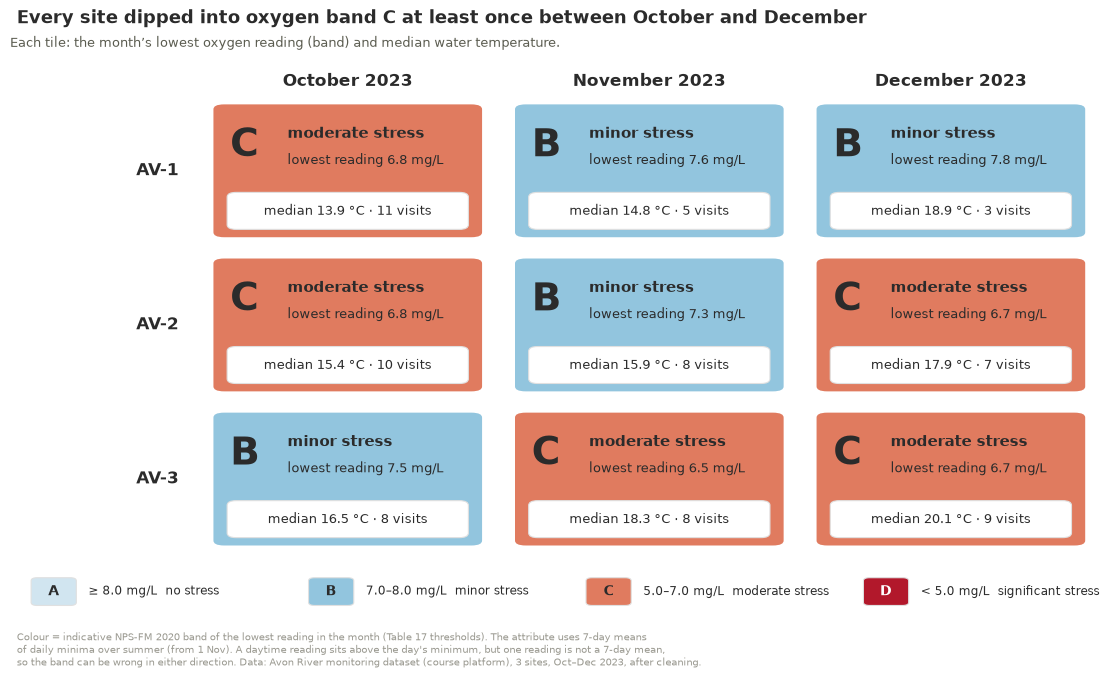

saved outputs/tables/02_river_check_grid.csv

site_id   month  n  do_min  temp_med band
   AV-1 2023-10 11     6.8     13.90    C
   AV-1 2023-11  5     7.6     14.80    B
   AV-1 2023-12  3     7.8     18.90    B
   AV-2 2023-10 10     6.8     15.35    C
   AV-2 2023-11  8     7.3     15.85    B
   AV-2 2023-12  7     6.7     17.90    C
   AV-3 2023-10  8     7.5     16.45    B
   AV-3 2023-11  8     6.5     18.25    C
   AV-3 2023-12  9     6.7     20.10    C


In [11]:
from decimal import Decimal, ROUND_HALF_UP

def one_decimal(x):
    """Round half up (16.45 -> 16.5): the median of an even number of 0.1 °C readings can end in 5."""
    return Decimal(f'{x:.2f}').quantize(Decimal('0.1'), rounding=ROUND_HALF_UP)


grid = (visits.groupby(['site_id', 'month'])
              .agg(n=('date', 'size'), do_min=('do_mg_l', 'min'), temp_med=('temperature_c', 'median'))
              .reset_index())
grid['band'] = grid.do_min.map(indicative_band)
month_order = sorted(grid.month.unique())

fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')
ax.set_xlim(-0.62, len(month_order)); ax.set_ylim(-0.42, len(SITES) + 0.25); ax.axis('off')
for r, site in enumerate(SITES):
    y = len(SITES) - 1 - r
    ax.text(-0.06, y + 0.5, site, ha='right', va='center', fontsize=12, fontweight='bold')
    for c, mo in enumerate(month_order):
        g = grid[(grid.site_id == site) & (grid.month == mo)].iloc[0]
        face, ink = BAND_STYLE[g['band']]
        ax.add_patch(FancyBboxPatch((c + 0.05, y + 0.06), 0.90, 0.88, facecolor=face, edgecolor='white', lw=2,
                                    boxstyle='round,pad=0,rounding_size=0.04'))
        ax.text(c + 0.11, y + 0.66, g['band'], fontsize=28, fontweight='bold', color=ink, va='center')
        ax.text(c + 0.30, y + 0.74, SHORT[g['band']], fontsize=11, fontweight='bold', color=ink, va='center')
        ax.text(c + 0.30, y + 0.57, f"lowest reading {g['do_min']:.1f} mg/L", fontsize=9, color=ink, va='center')
        ax.add_patch(FancyBboxPatch((c + 0.10, y + 0.12), 0.80, 0.24, facecolor='white', edgecolor=PALETTE['grid'],
                                    lw=0.8, boxstyle='round,pad=0,rounding_size=0.03'))
        ax.text(c + 0.5, y + 0.24, f"median {one_decimal(g['temp_med'])} °C · {g['n']} visits", ha='center', va='center',
                fontsize=9.5, color=PALETTE['text'])
for c, mo in enumerate(month_order):
    ax.text(c + 0.5, len(SITES) + 0.08, mo.strftime('%B %Y'), ha='center', va='center', fontsize=12, fontweight='bold')
x = -0.55
for band in 'ABCD':
    face, ink = BAND_STYLE[band]
    floor = {'A': '≥ 8.0', 'B': '7.0–8.0', 'C': '5.0–7.0', 'D': '< 5.0'}[band]
    ax.add_patch(FancyBboxPatch((x, -0.32), 0.15, 0.18, facecolor=face, edgecolor=PALETTE['grid'], lw=0.8,
                                boxstyle='round,pad=0,rounding_size=0.02'))
    ax.text(x + 0.075, -0.23, band, ha='center', va='center', fontsize=10, fontweight='bold', color=ink)
    ax.text(x + 0.19, -0.23, f'{floor} mg/L  {SHORT[band]}', va='center', fontsize=8.5)
    x += 0.92
footnote(fig, 'Colour = indicative NPS-FM 2020 band of the lowest reading in the month (Table 17 thresholds). The attribute uses '
              '7-day means\nof daily minima over summer (from 1 Nov). A daytime reading sits above the day\'s minimum, but one reading '
              'is not a 7-day mean,\nso the band can be wrong in either direction. ' + SOURCE)
finding_title(fig, ax, 'Every site dipped into oxygen band C at least once between October and December',
              'Each tile: the month’s lowest oxygen reading (band) and median water temperature.')
fig_c = save_fig(fig, '02_C_river_check_grid')
plt.show()
_ = save_table(grid.astype({'month': str}).round(2), '02_river_check_grid')

### Interpretation — Figure C (for non-specialist readers)

- **What it shows.** Each tile answers "how bad did oxygen get that month?" with a letter, a word and a
  colour.
  - Every site reaches band C at least once.
  - AV-2 and AV-3 do so in two of the three months.
  - AV-1's only band-C month is October, before the NPS-FM summer window opens on 1 November.
- **Why it works for non-specialists:**
  - **Equal tiles in a fixed order.** A "cartogram heatmap" avoids the area bias of a real map (Wilke, 2019, ch. 15).
  - **Banded colours.** These read more easily than a continuous scale (Wilke, 2019, ch. 15).
  - **The title states the finding** (Knaflic, 2015, ch. 1).
  - **Redundant coding.** The meaning survives colour blindness and greyscale; see the check below.
- **In production,** the grid would cover every site in river order and refresh each month from the
  monitoring data.

saved outputs/figures/02_D_fish_by_month.png


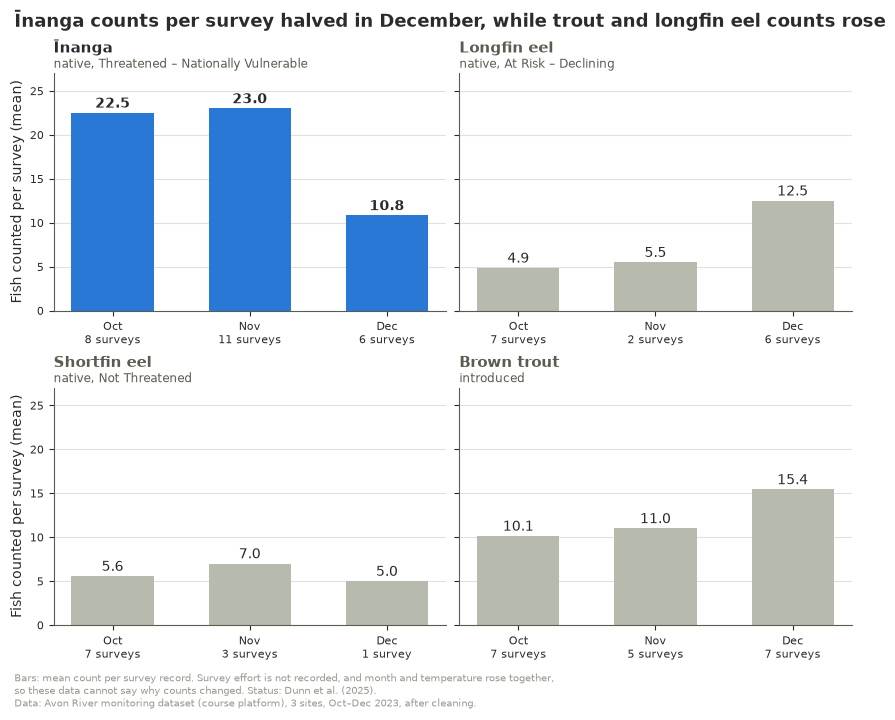

In [12]:
# Figure D: all four species on one scale, so the reader sees that īnanga is the exception.
per_survey = records.groupby(['species', 'month'])['count'].agg(['mean', 'size'])
month_list = sorted(records.month.unique())
means = per_survey['mean'].unstack()
# The title states the finding, so check it still holds for these data.
assert means.loc['Inanga', month_list[-1]] < 0.5 * means.loc['Inanga', month_list[:-1]].mean()
assert (means.loc[['Brown Trout', 'Longfin Eel'], month_list[-1]]
        > means.loc[['Brown Trout', 'Longfin Eel'], month_list[:-1]].max(axis=1)).all()

xpos = np.arange(len(month_list))
fig, axes = plt.subplots(2, 2, figsize=(8.5, 6.6), sharey=True, layout='constrained')
for ax, t in zip(axes.flat, TAXA.itertuples()):                      # TAXA order: īnanga first
    d = per_survey.loc[t.species].reindex(month_list)
    hi = t.species == 'Inanga'
    ax.bar(xpos, d['mean'], color=PALETTE['accent'] if hi else PALETTE['context'], width=0.6)
    for x, m in zip(xpos, d['mean']):
        ax.text(x, m + 0.6, f'{m:.1f}', ha='center', fontsize=10, fontweight='bold' if hi else 'normal')
    ax.set_xticks(xpos, [f"{mo.strftime('%b')}\n{n} survey{'s' if n != 1 else ''}"
                         for mo, n in zip(month_list, d['size'])])
    status = f'native, {t.nz_status}' if t.origin == 'native' else 'introduced'
    ax.set_title(t.display, loc='left', fontsize=11, fontweight='bold', pad=15,
                 color=PALETTE['text'] if hi else PALETTE['rule'])
    ax.annotate(status, (0, 1), xycoords='axes fraction', xytext=(0, 4), textcoords='offset points',
                fontsize=8.5, color=PALETTE['rule'])
    ax.set_ylim(0, 27); ax.grid(axis='x', visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel('Fish counted per survey (mean)')
footnote(fig, 'Bars: mean count per survey record. Survey effort is not recorded, and month and temperature rose together,\n'
              'so these data cannot say why counts changed. '
              'Status: Dunn et al. (2025).\n' + SOURCE)
fig.suptitle('Īnanga counts per survey halved in December, while trout and longfin eel counts rose',
             x=0.01, ha='left', fontsize=13)
fig_d = save_fig(fig, '02_D_fish_by_month')
plt.show()

### Interpretation — Figure D (for non-specialist readers)

- **The message: īnanga is the exception.** All four species share one scale. Īnanga is in colour and the
  rest are grey (Knaflic, 2015, ch. 4), so a reader sees the December drop and, in the same month, the rise in
  trout and longfin eel.
- **No claim of cause.** The title says what happened, not why. The footnote says month and temperature
  rose together and survey effort isn't recorded, so the data can't say why.
- **Sample sizes on the axis.** Each bar shows how many surveys sit behind it, including the single
  December survey of shortfin eel.
- **The statistics live elsewhere.** The test is in `03`: Kruskal–Wallis, Holm-adjusted p ≈ 0.03 for īnanga.
- **One point per figure.** It answers one question, "did the native fish change?" (Wilke, 2019, ch. 29).

,palette,view,closest pair,ΔE of closest pair
0,"used: sequential, pale -> dark",as designed,A-B,17.6
1,"used: sequential, pale -> dark","deuteranopia (red-green, most common)",A-B,17.7
2,"used: sequential, pale -> dark",protanopia (red-green),A-B,14.8
3,"used: sequential, pale -> dark",greyscale print,A-B,12.9
4,alternative: diverging (RdBu ends),as designed,A-B,45.5
5,alternative: diverging (RdBu ends),"deuteranopia (red-green, most common)",C-D,34.3
6,alternative: diverging (RdBu ends),protanopia (red-green),B-C,41.9
7,alternative: diverging (RdBu ends),greyscale print,B-C,2.2


saved outputs/figures/02_C_cvd_check.png


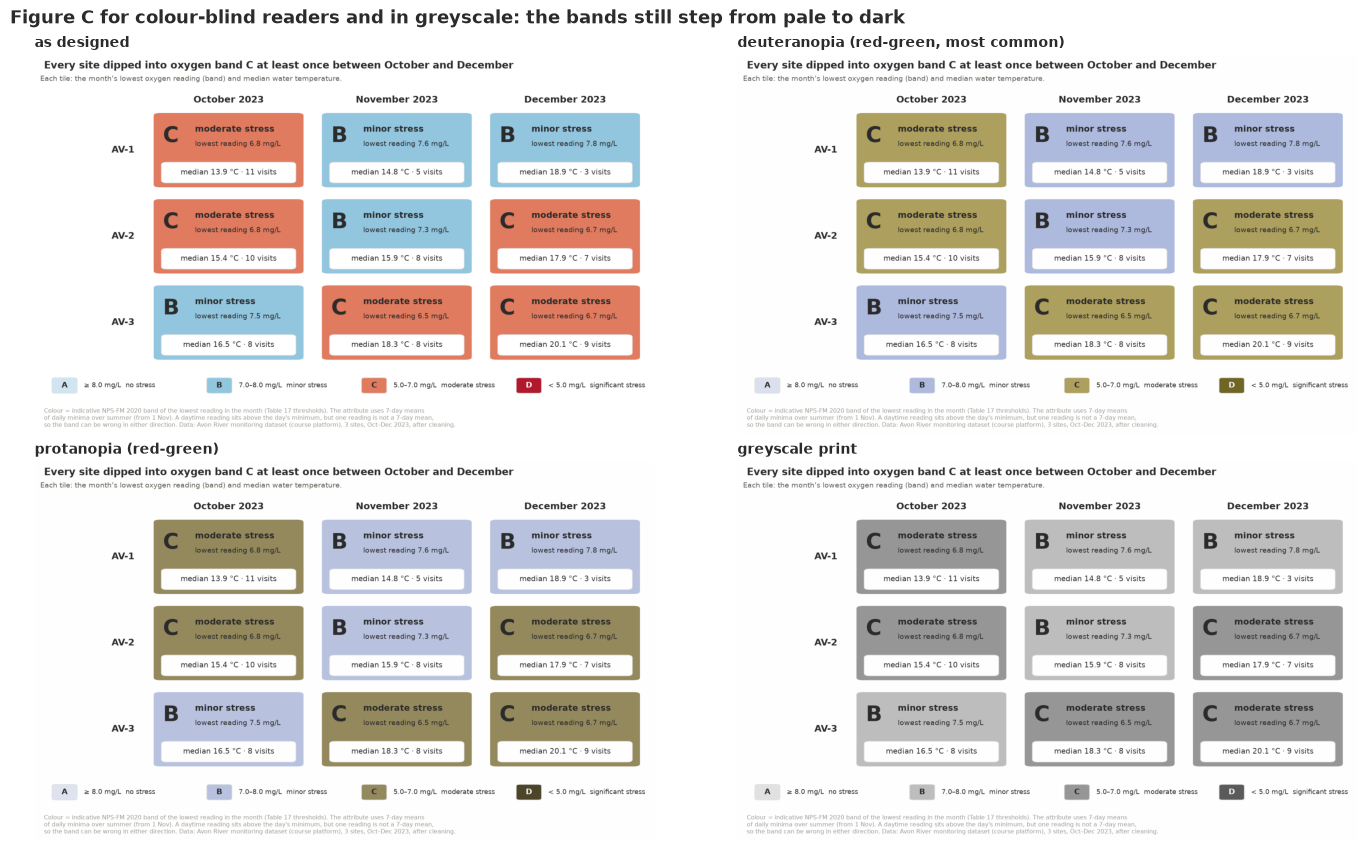

In [13]:
import itertools
from matplotlib import image as mpimg
from matplotlib.colors import to_rgb

# Machado, Oliveira & Fernandes (2009) simulation matrices (severity 1.0), applied in linear RGB.
CVD = {'deuteranopia (red-green, most common)': np.array([[0.367322, 0.860646, -0.227968],
                                                          [0.280085, 0.672501, 0.047413],
                                                          [-0.011820, 0.042940, 0.968881]]),
       'protanopia (red-green)': np.array([[0.152286, 1.052583, -0.204868],
                                           [0.114503, 0.786281, 0.099216],
                                           [-0.003882, -0.048116, 1.051998]])}
LUMA = np.array([0.2126, 0.7152, 0.0722])
VIEWS = ['as designed', *CVD, 'greyscale print']

def to_linear(c):
    return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

def to_srgb(c):
    c = np.clip(c, 0, 1)
    return np.where(c <= 0.0031308, 12.92 * c, 1.055 * c ** (1 / 2.4) - 0.055)

def simulate(rgb, view):
    rgb = np.asarray(rgb, dtype=float)
    if view == 'as designed':
        return rgb
    lin = to_linear(rgb)
    if view == 'greyscale print':
        return np.repeat(to_srgb(lin @ LUMA)[..., None], 3, axis=-1)
    return to_srgb(lin @ CVD[view].T)

def to_lab(rgb):
    m = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])
    xyz = (to_linear(rgb) @ m.T) / np.array([0.95047, 1.0, 1.08883])
    f = np.where(xyz > 0.008856, np.cbrt(xyz), 7.787 * xyz + 16 / 116)
    return np.stack([116 * f[..., 1] - 16, 500 * (f[..., 0] - f[..., 1]), 200 * (f[..., 1] - f[..., 2])], axis=-1)

# Measure, don't eyeball: the closest pair of band colours in each view, for the palette used and for a
# diverging alternative. Rough scale: ΔE ≈ 2 is barely noticeable, above 10 is clearly different.
PALETTES = {'used: sequential, pale -> dark': [BAND_STYLE[b][0] for b in 'ABCD'],
            'alternative: diverging (RdBu ends)': ['#2166ac', '#92c5de', '#f4a582', '#b2182b']}
rows = []
for pname, hexes in PALETTES.items():
    rgb = np.array([to_rgb(h) for h in hexes])
    for view in VIEWS:
        lab = to_lab(simulate(rgb, view))
        gaps = {f'{a}-{b}': float(np.linalg.norm(lab[i] - lab[j])) for (i, a), (j, b) in itertools.combinations(enumerate('ABCD'), 2)}
        closest = min(gaps, key=gaps.get)
        rows.append({'palette': pname, 'view': view, 'closest pair': closest, 'ΔE of closest pair': round(gaps[closest], 1)})
display(pd.DataFrame(rows))

img = mpimg.imread(fig_c)[..., :3]
fig, axes = plt.subplots(2, 2, figsize=(14, 8.4), layout='constrained')
for a, view in zip(axes.flat, VIEWS):
    a.imshow(simulate(img, view)); a.set_title(view, loc='left', fontsize=10); a.axis('off')
fig.suptitle('Figure C for colour-blind readers and in greyscale: the bands still step from pale to dark',
             x=0.01, ha='left', fontsize=13)
_ = save_fig(fig, '02_C_cvd_check')
plt.show()

### Interpretation — the colour-blindness and greyscale check

- **Bands stay apart in every view.** The closest pair of band colours stays clearly distinguishable in
  normal vision, under both common red–green deficiencies (Machado et al., 2009), and in greyscale
  (ΔE ≈ 13 or more, against roughly 2 for a just-noticeable difference).
- **Labels carry the meaning regardless.** The letters and words work even where colours converge.
- **Why this ramp.** The bands are ordered, so the palette is sequential, pale to dark (Wilke, 2019, chs. 4 and 19).
  The diverging alternative in the table looks fine in colour but fails in greyscale: its B and C bands
  become the same grey (ΔE ≈ 2).

## Sensitivity analysis: alternative versions of the cleaned data

Each scenario changes one cleaning rule from `01` and rebuilds the cleaned tables with the same code. `03`
compares the results.

In [14]:
# The four judgement calls from 01, each switched on its own, then the three that can apply
# together. Every version goes through the same clean() and derive(); 03 runs the same tests on each.
from src.paths import INTERIM

SCENARIOS = {
    'chosen': {},
    'same-day: first': {'WQ_SAME_DAY': 'first'},                # first of the 7 Dec readings, not the mean
    'row 64 = 12 Dec': {'REDATE_ROWS': {64: '2023-12-12'}},     # row 64's date is the error, not 77's
    'keep row 94': {'WQ_INVALID': {}},                          # DO 12.9 kept, averaged with row 69
    'drop row 45': {'SPECIES_MISSING': 'drop'},                 # missing species dropped, not inferred
}
SCENARIOS['64 + 94 + 45'] = {**SCENARIOS['row 64 = 12 Dec'], **SCENARIOS['keep row 94'], **SCENARIOS['drop row 45']}

scenario_dir = INTERIM / 'sensitivity'
scenario_dir.mkdir(parents=True, exist_ok=True)
built = []
for i, (name, change) in enumerate(SCENARIOS.items()):
    v, fc, _, _ = clean({**RULES, **change})
    v, r = derive(v, fc)
    v.drop(columns='month').to_csv(scenario_dir / f'{i}_visits.csv', index=False)
    r.drop(columns='month').to_csv(scenario_dir / f'{i}_records.csv', index=False)
    built.append({'scenario': name, 'parameters changed': ', '.join(change) or '-',
                  'visits': len(v), 'fish records': len(r)})
built = pd.DataFrame(built)
built.to_csv(scenario_dir / 'index.csv', index=False)
display(built)

,scenario,parameters changed,visits,fish records
0,chosen,-,69,70
1,same-day: first,WQ_SAME_DAY,69,70
2,row 64 = 12 Dec,REDATE_ROWS,70,70
3,keep row 94,WQ_INVALID,69,70
4,drop row 45,SPECIES_MISSING,69,69
5,64 + 94 + 45,"REDATE_ROWS, WQ_INVALID, SPECIES_MISSING",70,69


### Interpretation

- **Six versions of the cleaned data:** the chosen cleaning, each judgement call switched on its own, and
  the three that can apply together. "Same-day: first" stays out of the combination: with row 94 kept,
  taking the first reading would simply discard row 94 again.
- **Only judgement calls get a scenario.** The copies, the altered copies and the impossible values are
  settled by evidence in the file (`01`), so there is no credible alternative to test.
- **Next.** `03` runs the headline numbers and H1–H6 on every version.

## Findings: what the monitoring data supports

The formal tests are in `03`.

1. **The river warmed about 3 °C between October and December** (monthly means 15.0 → 16.6 → 18.1 °C).
   - AV-3 was warmest every month (median 17.9 °C, maximum 20.7 °C).
   - Sites differ significantly in temperature (`03`).
2. **Oxygen was below saturation on all 69 visits** (66–98%, median 81%).
   - **12 visits fell below 7 mg/L, at every site.**
   - Every site reached indicative band C at least once. AV-1's three low readings were all in October;
     from 1 November, when the NPS-FM summer window opens, only AV-2 (2) and AV-3 (5) fell below 7 mg/L.
   - These are daytime readings, so dawn minima were lower.
3. **Īnanga (native, Threatened – Nationally Vulnerable) counts per survey halved in December**
   (22.5 → 23.0 → 10.8). This is significant after correction (`03`). In the same month, introduced brown
   trout (10.1 → 15.4) and native longfin eel (4.9 → 12.5) counts rose.
4. **No species' count showed a statistically detectable association** with oxygen, saturation,
   temperature or pH at these sample sizes. The closest, longfin eel against temperature (ρ = 0.46,
   p = 0.08, n = 15), is not significant even before correction.
5. **Checked and ruled out.** pH stayed close to the lowland-river range (7.04–7.88; 10 of 68 readings just
   below 7.2, 1 above 7.8), and fish size did not change by month (īnanga 7.6, 7.7, 7.6 cm).
6. **Data quality.** 50 of 190 raw rows (26%) were copies, altered copies or invalid, including every
   row below Excel row 73. There are no sampling times and no survey effort.

## What this does not show

- **Why īnanga declined.** Warming, trout predation, migration timing and survey effort are all possible,
  and none is isolated here. Month and temperature rose together, so these data cannot separate them.
- **Summer conditions.** The data end on 29 December, before the summer period the NPS-FM bands are
  defined for.
- **True daily minima.** Without times or continuous loggers they are unknown. The excluded 12.9 mg/L
  reading is either an error or evidence of a large daily swing; the data can't tell which.

## Open questions for the data owner

1. Sampling times for every reading, and whether continuous loggers exist.
2. The fish survey method and effort (net type, duration, area), and whether every species caught is recorded.
3. The site order along the river, and what lies between the sites (outfalls, springs, the tidal reach).
4. How the copied rows entered the sheet, and why some carry changed dates or digits: re-entry, export
   or typing.

**Next:** `03` tests the hypotheses stated in advance, runs the sensitivity analysis and checks whether a
predictive model is justified.

## References

- Australian and New Zealand Environment and Conservation Council, & Agriculture and Resource Management
  Council of Australia and New Zealand. (2000). *Australian and New Zealand guidelines for fresh and marine
  water quality* (National Water Quality Management Strategy Paper No. 4).
- Benson, B. B., & Krause, D. (1984). The concentration and isotopic fractionation of oxygen dissolved in
  freshwater and seawater in equilibrium with the atmosphere. *Limnology and Oceanography, 29*(3), 620–632.
  https://doi.org/10.4319/lo.1984.29.3.0620
- Dunn, N. R., Closs, G. P., Crow, S. K., David, B. O., Goodman, J. M., Griffiths, M., Hicks, A. S.,
  Hickford, M. J. H., Jack, D. C., Kitson, J. C., Ling, N., Waters, J. M., Wylie, M. J., Hitchmough, R. A.,
  & Makan, T. (2025). *Conservation status of New Zealand freshwater fishes, 2023* (New Zealand Threat
  Classification Series 46). Department of Conservation.
  https://www.doc.govt.nz/globalassets/documents/science-and-technical/nztcs46.pdf
- Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*.
  Wiley.
- Machado, G. M., Oliveira, M. M., & Fernandes, L. A. F. (2009). A physiologically-based model for
  simulation of color vision deficiency. *IEEE Transactions on Visualization and Computer Graphics, 15*(6),
  1291–1298. https://doi.org/10.1109/TVCG.2009.113
- McDowall, R. M. (2006). Crying wolf, crying foul, or crying shame: Alien salmonids and a biodiversity
  crisis in the southern cool-temperate galaxioid fishes? *Reviews in Fish Biology and Fisheries, 16*(3–4),
  233–422. https://doi.org/10.1007/s11160-006-9017-7
- Ministry for the Environment. (2018). *A guide to attributes in Appendix 2 of the National Policy
  Statement for Freshwater Management (as amended 2017)*.
  https://environment.govt.nz/assets/Publications/Files/a-draft-guide-to-attributes.pdf
- Ministry for the Environment. (2020). *National Policy Statement for Freshwater Management 2020*. New
  Zealand Government. https://gazette.govt.nz/notice/id/2020-go3443
- Wilke, C. O. (2019). *Fundamentals of data visualization: A primer on making informative and compelling
  figures*. O'Reilly Media.